In [38]:
import pandas as pd
import numpy as np
from os import getcwd, listdir, path
import matplotlib.pyplot as plt
import sys
import ast
from glob import glob

import fitness.data_generating_process as dgp
import fitness.soga_fitness_SCM as soga_fitness_SCM
import fitness.interventions as interventions

In [39]:
# Read all pareto_fitness.txt files under results/causal_skills_tests and build aggregated stats
ex_name = 'diamond_no_if'
program = 'diamond'
base_dir = path.join('..', 'results', ex_name)
pattern = path.join(base_dir, '**', 'stats.tsv')

# Read ONLY the column best_fitness from all stats.tsv files, change the value tensor(-1000000.) to -1000000.0, and FOR EACH ROW compute mean, std, median and interquartile ranges (25, 75)
# and save the results in a new dataframe with columns: mean, std, median, q25, q75.Do not consider interventions.

files = glob(pattern, recursive=True)
dfs = []
for file in files:
    df = pd.read_csv(file, sep='\t')
    df['best_fitness'] = df['best_fitness'].replace('tensor(-1000000.)', -1000000.0).astype(float)
    dfs.append(df[['best_fitness']])

# for each row, compute mean, std, median, q25 and q75
results = []
for i in range(len(dfs[0])):
    values = [df['best_fitness'].iloc[i] for df in dfs]
    mean = np.mean(values)
    std = np.std(values)
    median = np.median(values)
    q25 = np.percentile(values, 25)
    q75 = np.percentile(values, 75)
    results.append({'mean': mean, 'std': std, 'median': median, 'q25': q25, 'q75': q75})

results_df = pd.DataFrame(results)
print(results_df)


               mean            std         median             q25         q75
0    -500173.234266  499826.765734 -500173.234266 -1000000.000000 -346.468531
1    -500173.234266  499826.765734 -500173.234266 -1000000.000000 -346.468531
2       -618.014329     271.545798    -618.014329     -889.560127 -346.468531
3       -270.298637      64.511038    -270.298637     -334.809675 -205.787598
4       -270.298637      64.511038    -270.298637     -334.809675 -205.787598
...             ...            ...            ...             ...         ...
1496    -101.367730       7.385644    -101.367730     -108.753373  -93.982086
1497    -101.367730       7.385644    -101.367730     -108.753373  -93.982086
1498    -101.367730       7.385644    -101.367730     -108.753373  -93.982086
1499    -101.367730       7.385644    -101.367730     -108.753373  -93.982086
1500    -101.367730       7.385644    -101.367730     -108.753373  -93.982086

[1501 rows x 5 columns]


In [40]:
vars, scm = dgp.get_vars(program)
real_program = dgp.get_real_program(program)
baseline_program = dgp.get_baseline_program(program)
#real_dataset = dgp.generate_interventional_dataset(scm, vars, 1000)

real_dataset_file = f'fitness/datasets/{program}.csv'
real_dataset = np.loadtxt(real_dataset_file, delimiter=',')

likelihood = soga_fitness_SCM.compute_likelihood(real_program, vars, real_dataset)
likelihood_base = soga_fitness_SCM.compute_likelihood(baseline_program, vars, real_dataset)

likelihood_intervened = 0
likelihood_base_intervened = 0
print(f'Likelihood of real program: {likelihood}')
print(f'\nLikelihood of baseline program: {likelihood_base}')
interventions_list = dgp.get_intervention_list(program)
for var, value in interventions_list:
    dataset_file = f'fitness/datasets/{program}_intervention_{var}_{value}.csv'
    data_intervened = np.loadtxt(dataset_file, delimiter=',')
    program_intervened = interventions.apply_intervention_to_program(real_program, var, value)
    baseline_program_intervened = interventions.apply_intervention_to_program(baseline_program, var, value)
    interventional_likelihood = soga_fitness_SCM.compute_likelihood(program_intervened, vars, data_intervened)
    interventional_likelihood_base = soga_fitness_SCM.compute_likelihood(baseline_program_intervened, vars, data_intervened)
    likelihood_intervened += interventional_likelihood
    likelihood_base_intervened += interventional_likelihood_base


likelihood = likelihood + likelihood_intervened
likelihood_base = likelihood_base + likelihood_base_intervened
print(f'Total likelihood of real program: {likelihood}')
print(f'Total likelihood of baseline program: {likelihood_base}')


Likelihood of real program: -8.631171666602551

Likelihood of baseline program: -13.469344876981827
Total likelihood of real program: -73.56194057052896
Total likelihood of baseline program: -123.17309295682675


In [41]:
# between all the files, find the one with best likelihood and print the corresponding program
best_likelihood = -np.inf
best_program = None
for file in files:
    df = pd.read_csv(file, sep='\t')
    df['best_fitness'] = df['best_fitness'].replace('tensor(-1000000.)', -1000000.0).astype(float)
    max_likelihood = df['best_fitness'].max()
    if max_likelihood > best_likelihood:
        best_likelihood = max_likelihood
        best_program = file 
print(f'Best likelihood: {best_likelihood}')
#print(f'Best program file: {best_program}')

#in the folder where the best stats.tsv file is, print the content of the best.txt file
best_program_file = best_program.replace('stats.tsv', 'best.txt')
with open(best_program_file, 'r') as f:
    best_program_content = f.read()
print(f'Best program content:\n{best_program_content}')

Best likelihood: -93.98208635353096
Best program content:
Generation:
1500

Phenotype:
13
V1 = uniform([+2.8e0, 2.1e1], 2);
V2 = +4.0e1;
V2 = V2 + gm([4.6e0, -2.9e1, 2.2e0]);
V3 = +0.6e0;
V3 = V3 + uniform([+1.3e0, 6.0e0], 2);
V4 = -V1 * -V1 - -5.1e1 * +V3 + -V2;
V4 = V4 + gm([7.9e1, +3.0e0, 8.2e0]);

Pre-processed Program
:T = uniform([2.800000, 23.800000], 2);F = 40;F = F + gm([1.000000], [-29], [2.2]);C = 0.6;C = C + uniform([1.300000, 7.300000], 2);TEMP0 = T * T;TEMP1 = -51 * C;E = TEMP0;E = E - TEMP1;E = E - F;E = E + gm([1.000000], [3], [8.2]);Genotype:
[60, 420, 146, 317, 178, 365, 108, 312, 448, 474, 293, 182, 271, 247, 125, 124, 472, 151, 222, 498, 94, 170, 349, 60, 299, 196, 225, 374, 386, 102, 240, 7, 472, 49, 405, 30, 392, 172, 206, 310, 468, 300, 429, 112, 172, 180, 146, 78, 443, 358, 103, 14, 451, 273, 260, 138, 226, 90, 106, 296, 433, 203, 380, 167, 482, 274, 15, 63, 478, 181, 57, 387, 335, 12, 89, 398, 51, 435, 471, 393, 346, 116, 386, 356, 206, 20, 193, 466, 34, 164, 4

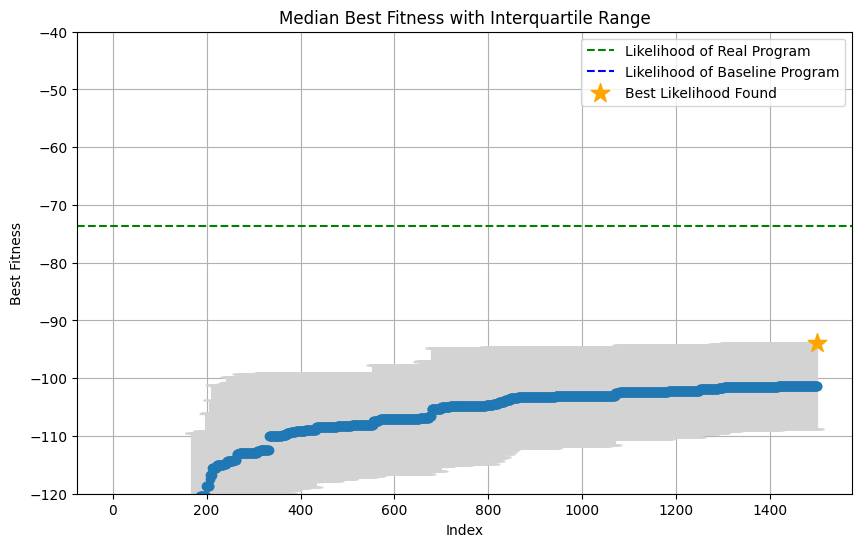

In [42]:
# Plot results_df median with error bars for q25 and q75
plt.figure(figsize=(10, 6))
plt.errorbar(results_df.index, results_df['median'], yerr=[results_df['median'] - results_df['q25'], results_df['q75'] - results_df['median']], fmt='o', ecolor='lightgray', capsize=5)
plt.title('Median Best Fitness with Interquartile Range')
plt.xlabel('Index')
plt.ylabel('Best Fitness')
plt.ylim(-120, -40)

# Add a horizontal line for the likelihood of the real program and the baseline program
plt.axhline(y=likelihood, color='g', linestyle='--', label='Likelihood of Real Program')
plt.axhline(y=likelihood_base, color='b', linestyle='--', label='Likelihood of Baseline Program')

# Add a point for the best likelihood found in the files with the shape of a star and color orange
plt.scatter(len(results_df)-1, best_likelihood, color='orange', label='Best Likelihood Found', zorder=5, marker='*', s=200)

plt.legend()

plt.grid()
plt.show()

In [ ]:
no_int_ex_name = 'diamond_no_interventions'

# Read all best.txt files under results/chain_no_interventions and compute the likelihood of the program in each best.txt file (it's between "Pre-processed Program \n :" and "Tree:")
pattern_no_int = path.join('..', 'results', no_int_ex_name, '**', 'best.txt')
files_no_int = glob(pattern_no_int, recursive=True)
likelihoods_no_int = []
likelihoods_no_int_no_interventions = []
for file in files_no_int:
    with open(file, 'r') as f:
        content = f.read()
    program_start = content.find('Pre-processed Program') + len('Pre-processed Program')
    program_end = content.find('Genotype:')
    program_str = content[program_start:program_end].strip()
    #remove the : at the beginning
    program_str = program_str.lstrip(':')
    #print(f'Program string:\n{program_str}')
    #program_ast = ast.literal_eval(program_str)
    likelihood_no_int_no_interventions = soga_fitness_SCM.compute_likelihood(program_str, vars, real_dataset)
    #print(f'Likelihood of program found without interventions: {likelihood_no_int}')
    interventions_list = dgp.get_intervention_list(program)
    likelihood_no_int = likelihood_no_int_no_interventions
    for var, value in interventions_list:
        dataset_file = f'fitness/datasets/{program}_intervention_{var}_{value}.csv'
        data_intervened = np.loadtxt(dataset_file, delimiter=',')
        program_intervened = interventions.apply_intervention_to_program(program_str, var, value)
        #print(f'Program intervened:\n{program_intervened}')
        interventional_likelihood = soga_fitness_SCM.compute_likelihood(program_intervened, vars, data_intervened)
        #print(f'Interventional likelihood for intervention {var}={value}: {interventional_likelihood}')
        likelihood_no_int += interventional_likelihood

    likelihoods_no_int.append(likelihood_no_int)
    likelihoods_no_int_no_interventions.append(likelihood_no_int_no_interventions)
print(f'Likelihoods of programs found without interventions: {likelihoods_no_int}')

Program string:
F = gm([1.000000], [9.6], [3]);C = 8.2;C = C + gm([1.000000], [2], [8.2]);TEMP0 = 3.96 * F;TEMP0 = TEMP0 * C;TEMP1 = 68 * C;E = TEMP0;E = E + TEMP1;E = E + uniform([9.600000, 12.600000], 2);T = 8.2;T = T + gm([1.000000], [2], [8.2]);
Likelihood of program found without interventions: -15.294930804496975
Program string:
C = uniform([2.900000, 7.100000], 2);TEMP0 = 0.7 * C;T = TEMP0;T = T + uniform([0.700000, 20.700000], 2);TEMP1 = 5.4 * C;TEMP1 = TEMP1 * T;E = TEMP1;E = E + gm([1.000000], [87], [48]);F = C;F = F + uniform([2.600000, 7.700000], 2);
Likelihood of program found without interventions: -11.563374525617194
Program string:
C = uniform([-7.400000, 32.600000], 2);TEMP0 = 2.6 * C;TEMP0 = TEMP0 * C;TEMP1 = -84 * C;TEMP2 = C * C;E = TEMP0;E = E - TEMP1;E = E + TEMP2;E = E + uniform([-23.000000, -17.600000], 2);F = 0.7;F = F + C;F = F + uniform([2.000000, 7.000000], 2);T = 0;T = T - E;T = T + E;T = T + uniform([-7.400000, 32.600000], 2);
Likelihood of program found w